In [89]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import preprocessing
from sklearn import feature_selection
from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv('/Users/sathishkumar/Learnings/Data Science Journey/Projects/UrbanCompany/data_assignment.gz')

## Let us have a quick look at the dataframe

In [4]:
df.head()

,order_id,provider_id,is_exclusive_lead,bookingslot,ns_count_1day,ns_count_3day,ns_count_1week,ns_count_1month,ns_count_6month,responded_lead_1day,...,days_no_block_in_6month,days_block_in_6month,number_times_blocked_in_6month,avg_order_value_1day,avg_order_value_3day,avg_order_value_1week,avg_order_value_1month,avg_order_value_3month,avg_order_value_6month,ns
0,62107eff2938da280068c2c9,5e37b5f496d3362500c710d4,0,AfterNoon,0,0,0,1,5,2,...,178,2,1,0.0,157.833333,352.923077,479.406250,399.288660,363.672646,0
1,62107eff2938da280068c2c9,5e58e2df14f8c026008e454a,0,AfterNoon,0,0,0,1,4,2,...,180,0,0,372.0,302.857143,382.400000,421.212121,384.906832,347.167742,0
2,62107eff2938da280068c2c9,5f7182270446792500c1005a,0,AfterNoon,0,0,1,1,1,3,...,180,0,0,249.0,149.400000,411.800000,339.971429,273.268041,225.731132,0
3,62107eff2938da280068c2c9,5f0c7eb39eb3c12500d7af80,0,AfterNoon,0,0,0,1,19,2,...,179,0,0,0.0,406.285714,255.181818,342.552632,422.446512,386.900000,0
4,6210830ba014f82a00115ca2,59f8630a8378405d001603d0,0,AfterNoon,0,0,0,0,1,2,...,180,0,0,114.5,162.428571,183.400000,186.033708,162.231034,169.665428,1


In [5]:
df.describe()

,is_exclusive_lead,ns_count_1day,ns_count_3day,ns_count_1week,ns_count_1month,ns_count_6month,responded_lead_1day,responded_lead_3day,responded_lead_1week,responded_lead_1month,...,days_no_block_in_6month,days_block_in_6month,number_times_blocked_in_6month,avg_order_value_1day,avg_order_value_3day,avg_order_value_1week,avg_order_value_1month,avg_order_value_3month,avg_order_value_6month,ns
count,181859.000000,181859.000000,181859.000000,181859.000000,181859.000000,181859.000000,181859.000000,181859.000000,181859.000000,181859.000000,...,181859.000000,181859.000000,181859.000000,181859.000000,181859.000000,181859.000000,181859.000000,181859.000000,181859.000000,181859.000000
mean,0.496522,0.093457,0.232427,0.497182,1.780088,7.315728,4.374917,10.408184,21.998438,80.131899,...,142.616912,12.076466,1.576441,310.426698,313.480084,319.031365,316.764393,312.850744,304.313977,0.030843
std,0.499989,0.318427,0.650514,1.089268,3.525125,11.993632,2.338761,6.329426,13.300968,47.262086,...,48.492493,24.121458,2.034664,370.083119,299.796860,267.157706,235.805493,231.536775,220.455039,0.172892
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,2.000000,2.000000,...,1.000000,0.000000,0.000000,-29.333333,-13.666667,-13.666667,-13.666667,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,3.000000,7.000000,14.000000,49.000000,...,119.000000,0.000000,0.000000,77.142857,114.000000,131.204167,139.410959,136.027431,131.701190,0.000000
50%,0.000000,0.000000,0.000000,0.000000,1.000000,4.000000,4.000000,9.000000,20.000000,73.000000,...,168.000000,2.000000,1.000000,194.200000,219.545455,235.933333,245.227273,245.561111,241.509383,0.000000
75%,1.000000,0.000000,0.000000,1.000000,2.000000,9.000000,5.000000,13.000000,27.000000,103.000000,...,179.000000,12.000000,2.000000,413.000000,422.571429,437.166667,442.777778,443.228481,435.411765,0.000000
max,1.000000,7.000000,15.000000,25.000000,99.000000,369.000000,34.000000,91.000000,171.000000,663.000000,...,180.000000,179.000000,21.000000,6802.000000,5897.000000,4727.857143,3490.434783,3116.800000,3049.682540,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181859 entries, 0 to 181858
Data columns (total 75 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   order_id                        181859 non-null  object 
 1   provider_id                     181859 non-null  object 
 2   is_exclusive_lead               181859 non-null  int64  
 3   bookingslot                     181859 non-null  object 
 4   ns_count_1day                   181859 non-null  int64  
 5   ns_count_3day                   181859 non-null  int64  
 6   ns_count_1week                  181859 non-null  int64  
 7   ns_count_1month                 181859 non-null  int64  
 8   ns_count_6month                 181859 non-null  int64  
 9   responded_lead_1day             181859 non-null  int64  
 10  responded_lead_3day             181859 non-null  int64  
 11  responded_lead_1week            181859 non-null  int64  
 12  responded_lead_1

In [7]:
df.dtypes.sort_values()

ns                                  int64
delivered_lead_3month               int64
delivered_lead_6month               int64
number_times_blocked_in_6month      int64
days_block_in_6month                int64
                                   ...   
total_income_1week                float64
Acceptance_Rate_3MONTH            float64
bookingslot                        object
provider_id                        object
order_id                           object
Length: 75, dtype: object

In [8]:
df = pd.concat([df,pd.get_dummies(df.bookingslot,prefix='IsBookingSlot')],axis = 1)

In [9]:
print('No. of cells with NULL values :\t',sum(df.isnull().sum()))
print('No. of cells with NA values :\t',sum(df.isna().sum()))

No. of cells with NULL values :	 0
No. of cells with NA values :	 0


# Quick statistics about the data

In [10]:
print('Length of the data :\t\t', len(df))
print('Number of orders :\t\t', len(df.order_id.unique()))


Length of the data :		 181859
Number of orders :		 122917


In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_exclusive_lead,181859.0,0.496522,0.499989,0.0,0.0,0.0,1.0,1.0
ns_count_1day,181859.0,0.093457,0.318427,0.0,0.0,0.0,0.0,7.0
ns_count_3day,181859.0,0.232427,0.650514,0.0,0.0,0.0,0.0,15.0
ns_count_1week,181859.0,0.497182,1.089268,0.0,0.0,0.0,1.0,25.0
ns_count_1month,181859.0,1.780088,3.525125,0.0,0.0,1.0,2.0,99.0
...,...,...,...,...,...,...,...,...
ns,181859.0,0.030843,0.172892,0.0,0.0,0.0,0.0,1.0
IsBookingSlot_AfterNoon,181859.0,0.548887,0.497606,0.0,0.0,1.0,1.0,1.0
IsBookingSlot_Evening,181859.0,0.298984,0.457814,0.0,0.0,0.0,1.0,1.0
IsBookingSlot_Morning,181859.0,0.143727,0.350813,0.0,0.0,0.0,0.0,1.0


In [22]:
df_grp_by_order = df.groupby(['order_id']).count().sort_values(by = ['provider_id'],ascending=False)[['provider_id']]
df_grp_by_order[df_grp_by_order.provider_id > 1]

,provider_id
order_id,
61f50b4814aadd28008d54d2,35
61f51a480afe9f2800b9fcfe,29
61e9581240dcad280073d2be,29
61b39226e2ff3725007d9cde,27
61ce8c9121d9c72400870c56,27
...,...
61dad803fc4c922600b4dd7a,2
61a700502b453d2800509df7,2
61a700472b453d2800509de6,2


In [23]:
df[df.order_id == '61f50b4814aadd28008d54d2']

,order_id,provider_id,is_exclusive_lead,bookingslot,ns_count_1day,ns_count_3day,ns_count_1week,ns_count_1month,ns_count_6month,responded_lead_1day,...,days_no_block_in_6month,days_block_in_6month,number_times_blocked_in_6month,avg_order_value_1day,avg_order_value_3day,avg_order_value_1week,avg_order_value_1month,avg_order_value_3month,avg_order_value_6month,ns
54658,61f50b4814aadd28008d54d2,5d492fa367b76022000c0148,1,AfterNoon,0,0,0,0,1,4,...,167,13,7,392.500000,392.500000,630.000000,525.568182,495.183544,453.202312,0
54659,61f50b4814aadd28008d54d2,6151af36e6c3b9290070e78d,0,AfterNoon,0,1,4,11,28,2,...,106,0,0,179.500000,126.333333,204.080000,225.000000,238.651786,238.651786,0
54660,61f50b4814aadd28008d54d2,5fe96332b8842d2500381d6f,0,AfterNoon,0,0,0,3,19,2,...,178,2,1,0.000000,0.000000,172.800000,201.827586,227.506726,229.526807,0
54661,61f50b4814aadd28008d54d2,5d64f84611328123002b1ca4,0,AfterNoon,0,0,0,0,1,3,...,180,0,0,149.333333,149.375000,231.400000,245.630137,216.891566,219.907631,0
54662,61f50b4814aadd28008d54d2,5f09f0b061983c2500ed4453,0,AfterNoon,0,0,0,1,7,3,...,174,6,3,270.666667,270.666667,307.263158,258.157895,231.641148,240.275294,0
54663,61f50b4814aadd28008d54d2,5f2e36800f81dc2500087c86,0,AfterNoon,0,0,1,1,7,2,...,167,13,6,921.500000,921.500000,464.090909,440.636364,427.317460,424.519512,0
54664,61f50b4814aadd28008d54d2,618e86c8d196622900374dd5,0,AfterNoon,0,0,0,0,1,2,...,66,0,0,224.500000,494.333333,235.642857,223.576923,215.513966,215.513966,0
54665,61f50b4814aadd28008d54d2,5fed8a2b8fd8a9250023545d,0,AfterNoon,0,0,0,0,3,7,...,177,3,1,282.000000,282.923077,196.933333,212.738806,217.253191,215.220879,0
54666,61f50b4814aadd28008d54d2,5dc11a5777a0d72500b8accd,0,AfterNoon,0,0,1,1,3,4,...,141,2,1,340.000000,329.714286,335.833333,229.520833,235.832558,234.467532,0
54667,61f50b4814aadd28008d54d2,5f967564aacfdc2800f1bb6b,0,AfterNoon,0,0,0,0,0,5,...,22,0,0,184.400000,253.428571,211.454545,193.812500,193.812500,193.812500,0


In [51]:
#let us check the uniques values the column 'ns' have
print(df.ns.unique())
print('Overall percentage of no show :\t',round(sum(df.ns)/len(df)*100,2),'%')

[0 1]
Overall percentage of no show :	 3.08 %


### there are over 70 independant variables. Let us find how each of them are correlated to the no show variable

<Axes: >

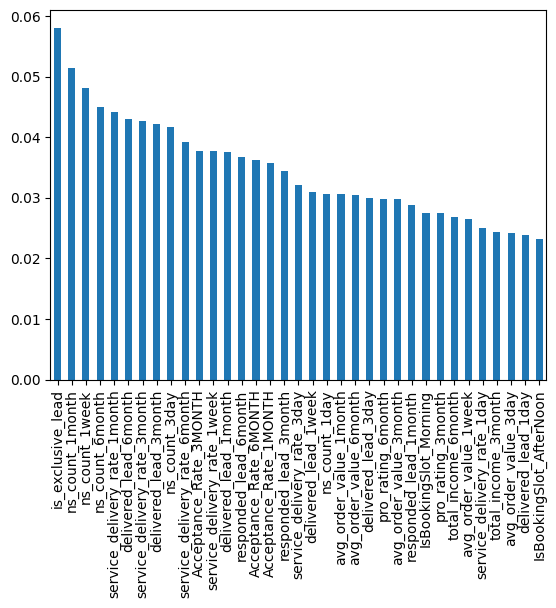

In [20]:
df.drop(columns=['ns']).corrwith(other= df.ns).abs().sort_values(ascending = False).head(35).plot(kind = 'bar')

It is seen that 'is_exclusive_lead' and 'ns_count%' variables account for the top correlations with the dependant variable. However, with this info, there is no evidence to show that any of these parameters have a strong correlation with 'no_show'

<Axes: xlabel='bookingslot', ylabel='ns'>

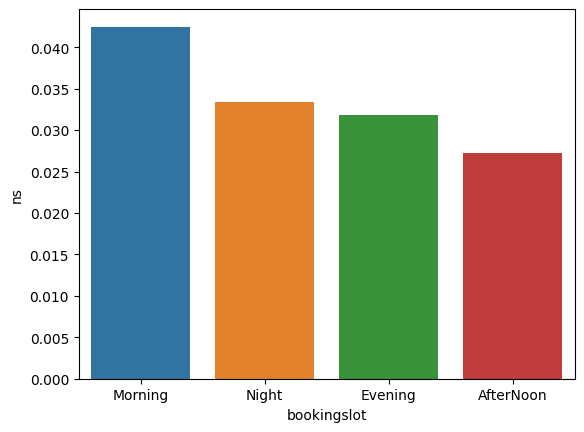

In [47]:
# Let us plot and see how no show booking slot
sns.barplot(df.groupby(by = ['bookingslot']).mean()[['ns']].sort_values(by = ['ns'],ascending = False).reset_index(), x = 'bookingslot',y='ns')

In [88]:
corr_df = df.corr()
corr_df_cols = corr_df.columns
corr_lst = []
for row in corr_df.values:
    corr_lst.append((corr_df_cols[abs(row).argsort()[-2]],corr_df_cols[abs(row).argsort()[-3]],row[abs(row).argsort()[-3]]))
corr_df_new = pd.DataFrame(corr_lst, columns= ['col1','col2','max_corr'])
print(corr_df_new)

                       col1                     col2  max_corr
0         is_exclusive_lead          ns_count_6month -0.066827
1             ns_count_1day            ns_count_3day  0.616127
2             ns_count_3day           ns_count_1week  0.810199
3            ns_count_1week            ns_count_3day  0.810199
4           ns_count_1month          ns_count_6month  0.798791
..                      ...                      ...       ...
71                       ns        is_exclusive_lead -0.058140
72  IsBookingSlot_AfterNoon    IsBookingSlot_Evening -0.720376
73    IsBookingSlot_Evening  IsBookingSlot_AfterNoon -0.720376
74    IsBookingSlot_Morning  IsBookingSlot_AfterNoon -0.451920
75      IsBookingSlot_Night  IsBookingSlot_AfterNoon -0.101537

[76 rows x 3 columns]


# Feature Scaling

# Feature Selection

In [94]:
X = df.drop(columns = ['order_id','provider_id','bookingslot','ns','ns_new'])
y = df.ns

In [116]:
#check how many columns have infinity value in it
df.max().isin([np.inf]).sum()

3

In [108]:
df.Acceptance_Rate_1DAY.replace(np.inf, df.Acceptance_Rate_1DAY.max(), inplace=True)

,order_id,provider_id,is_exclusive_lead,bookingslot,ns_count_1day,ns_count_3day,ns_count_1week,ns_count_1month,ns_count_6month,responded_lead_1day,...,avg_order_value_1week,avg_order_value_1month,avg_order_value_3month,avg_order_value_6month,ns,IsBookingSlot_AfterNoon,IsBookingSlot_Evening,IsBookingSlot_Morning,IsBookingSlot_Night,ns_new
7,620a78c0c5b9832900fffb0e,59197ab4035210122be405c0,0,Evening,1,2,2,4,10,2,...,785.777778,717.500000,529.692308,440.485981,0,0,1,0,0,no
26,620fd769a6ab4b290021063f,5ee986e90b2de92600a1fa86,0,AfterNoon,0,0,0,1,1,4,...,167.857143,401.258621,427.053571,397.823256,0,1,0,0,0,no
50,62107a65e11b412700454da1,5aed8c6f7e598e37008e40df,0,AfterNoon,0,0,1,1,10,2,...,286.916667,357.909091,339.336449,301.187266,0,1,0,0,0,no
51,62107b3a9360c32c00976887,59197ab4035210122be405c0,0,AfterNoon,1,2,2,4,10,2,...,785.777778,717.500000,529.692308,440.485981,0,1,0,0,0,no
83,621078f9ac40352900c1f634,60efb183fb83ed27005b1449,0,AfterNoon,0,0,1,1,6,3,...,306.250000,371.076923,315.666667,225.485050,0,1,0,0,0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181772,61a6fb502b453d280050976f,5bcdc31e7a7d392200827795,1,AfterNoon,0,0,1,1,1,3,...,613.411765,490.456140,485.697531,381.060714,0,1,0,0,0,no
181786,61a70e3b86491029002fd000,6075277bf3d5b6250089b6f1,1,AfterNoon,0,0,0,0,0,2,...,411.312500,308.375000,326.633333,326.633333,0,1,0,0,0,no
181797,61a6e34391c6932800a248ba,613b8d0925e757290030a0ef,0,AfterNoon,0,0,0,0,0,2,...,363.500000,363.500000,363.500000,363.500000,0,1,0,0,0,no
181840,61a681b52b453d2800502b23,5732dfdcb5959105684e20cd,0,AfterNoon,0,0,0,0,1,3,...,174.250000,127.809524,102.543590,102.543590,0,1,0,0,0,no


In [95]:
model = LinearRegression()
model.fit(X, y)
importance = model.coef_
for i,v in enumerate(importance):
	print('Feature: %0d, Score: %.5f' % (i,v))
# plot feature importance
sns.barplot([x for x in range(len(importance))], importance)

ValueError: Input X contains infinity or a value too large for dtype('float64').

In [ ]:
# feature_selection.RFECV()